In [1]:
!pip install pandas numpy scikit-learn xgboost lightgbm scipy matplotlib seaborn

  Using cached pandas-3.0.3-cp313-cp313-win_amd64.whl.metadata (19 kB)
  Using cached numpy-2.4.6-cp313-cp313-win_amd64.whl.metadata (6.6 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached tzdata-2026.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp313-cp313-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp313-cp313-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.2.0-cp313-cp313-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached pandas-3.0.3-cp313-cp313-win_amd64.whl (9.8 MB)
Using cached numpy-2.4.6-cp313-cp313-win_amd64.whl (12.3 MB)
   --------------------------------------

### Group 9 - Malayo Ang Lipad, Mababaw Ang Pundasyon: Philippine Export Vulnerability and Trade Potential Analysis Using Machine Learning and Anomaly Detection 


##### Data Import and Preprocessing

##### 1. Growth & Efficiency


##### 2. Strengths & Vulnerabilities



Current Commodity Danger

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest

# ---- CONFIG -----------------------------------------------------------------
INPUT_CSV = "combined.csv"        # <-- path to your combined CSV
PRE_PANDEMIC_CUTOFF = 2020        # years < this = "pre-pandemic"
N_CURRENT_YEARS = 1               # how many of the most recent years = "current"
CONTAMINATION = 0.15              # expected proportion of "in danger" commodities
RANDOM_STATE = 42
TOP_N = 10                        # how many commodities to show in the bar chart

# ---- 1. LOAD ------------------------------------------------------------
df = pd.read_csv(INPUT_CSV)
df["Year"] = df["Year"].astype(int)
df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")
df["FOB"] = pd.to_numeric(df["FOB"], errors="coerce")

df.head()

,Commodity,Country Of Destination,Year,Quantity,FOB,source_file
0,Abaca Fibers,Bangladesh,2020,180.00,49500.0,PhilippineExports(2020-2021).csv
1,Abaca Fibers,Bangladesh,2022,11226.86,27900.0,PhilippineExports(2022-2023).csv
2,Abaca Fibers,Bangladesh,2024,33750.00,83250.0,PhilippineExports(2024-2025).csv
3,Abaca Fibers,Egypt Arab Republic,2018,720.00,191880.0,PhilippineExports(2018-2019).csv
4,Abaca Fibers,Egypt Arab Republic,2019,360.00,85320.0,PhilippineExports(2018-2019).csv


In [9]:
# =============================================================================
# EDA — Structural Checks
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("combined.csv")
df["Year"] = df["Year"].astype(int)
df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")
df["FOB"] = pd.to_numeric(df["FOB"], errors="coerce")

print("Shape:", df.shape)
print("\nDtypes / non-null counts:")
df.info()

print("\nRows per year:")
print(df["Year"].value_counts().sort_index())

print("\nDuplicate (Commodity, Country, Year) rows:",
      df.duplicated(subset=["Commodity", "Country Of Destination", "Year"]).sum())

print("\nUnique commodities:", df["Commodity"].nunique())
print("Unique countries:", df["Country Of Destination"].nunique())

print("\nYears of data available per commodity (min/max/median):")
years_per_commodity = df.groupby("Commodity")["Year"].nunique()
print(years_per_commodity.describe()[["min", "50%", "max"]])

print("\nCommodities with pre-2020 data:",
      df.loc[df["Year"] < 2020, "Commodity"].nunique(), "of", df["Commodity"].nunique())

Shape: (30444, 6)

Dtypes / non-null counts:
<class 'pandas.DataFrame'>
RangeIndex: 30444 entries, 0 to 30443
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Commodity               30444 non-null  str    
 1   Country Of Destination  30444 non-null  str    
 2   Year                    30444 non-null  int64  
 3   Quantity                30444 non-null  float64
 4   FOB                     30444 non-null  float64
 5   source_file             30444 non-null  str    
dtypes: float64(2), int64(1), str(3)
memory usage: 1.4 MB

Rows per year:
Year
2018    4055
2019    3888
2020    3722
2021    3815
2022    3721
2023    3687
2024    3684
2025    3872
Name: count, dtype: int64

Duplicate (Commodity, Country, Year) rows: 0

Unique commodities: 73
Unique countries: 255

Years of data available per commodity (min/max/median):
min    1.0
50%    8.0
max    8.0
Name: Year, dtype: float64

Commodities wit

In [5]:
# ---- 2. PREPROCESS / FEATURE ENGINEERING --------------------------------
# Aggregate country-level rows into one row per Commodity-Year
yearly = (
    df.groupby(["Commodity", "Year"], as_index=False)[["Quantity", "FOB"]]
    .sum()
)

last_year = yearly["Year"].max()
current_years = list(range(last_year - N_CURRENT_YEARS + 1, last_year + 1))
pre_years = sorted(y for y in yearly["Year"].unique() if y < PRE_PANDEMIC_CUTOFF)

if not pre_years:
    raise ValueError(
        f"No years before {PRE_PANDEMIC_CUTOFF} found in the data — "
        "can't compute a pre-pandemic baseline."
    )

baseline = (
    yearly[yearly["Year"].isin(pre_years)]
    .groupby("Commodity", as_index=False)[["Quantity", "FOB"]]
    .mean()
    .rename(columns={"Quantity": "baseline_qty", "FOB": "baseline_fob"})
)
current = (
    yearly[yearly["Year"].isin(current_years)]
    .groupby("Commodity", as_index=False)[["Quantity", "FOB"]]
    .mean()
    .rename(columns={"Quantity": "current_qty", "FOB": "current_fob"})
)

feat = baseline.merge(current, on="Commodity", how="inner")

# Drop commodities with a ~zero baseline — % change is meaningless/explodes
feat = feat[feat["baseline_fob"] > 0].copy()

# Core "danger" signals: % change from pre-pandemic baseline
feat["pct_change_fob"] = (feat["current_fob"] - feat["baseline_fob"]) / feat["baseline_fob"]
feat["pct_change_qty"] = (feat["current_qty"] - feat["baseline_qty"]) / feat["baseline_qty"]

# Volatility: how much this commodity bounces around year to year
yoy = yearly.sort_values(["Commodity", "Year"]).copy()
yoy["fob_pct_change_yoy"] = yoy.groupby("Commodity")["FOB"].pct_change()
volatility = (
    yoy.groupby("Commodity")["fob_pct_change_yoy"]
    .std()
    .rename("volatility")
    .reset_index()
)
feat = feat.merge(volatility, on="Commodity", how="left")
feat["volatility"] = feat["volatility"].fillna(0)

# Scale of the commodity (context for plotting, not fed to the model)
feat["baseline_fob_share"] = feat["baseline_fob"] / feat["baseline_fob"].sum()

# Clean up any remaining inf/NaN
feat = feat.replace([np.inf, -np.inf], np.nan)
feat = feat.dropna(subset=["pct_change_fob", "pct_change_qty", "volatility"])
feat = feat.reset_index(drop=True)

print(f"{len(feat)} commodities with usable pre-pandemic baselines")
feat.head()

65 commodities with usable pre-pandemic baselines


,Commodity,baseline_qty,baseline_fob,current_qty,current_fob,pct_change_fob,pct_change_qty,volatility,baseline_fob_share
0,Abaca Fibers,1.241920e+05,3.017251e+07,1.252361e+07,2.172388e+07,-0.280011,99.840714,0.239150,0.000431
1,Activated Carbon,7.471295e+07,1.298517e+08,6.994068e+07,1.538772e+08,0.185022,-0.063875,0.201407,0.001854
2,Articles Of Apparel,2.948637e+08,9.510190e+08,8.737448e+07,6.888137e+08,-0.275710,-0.703678,0.162505,0.013581
3,"Baby Carriage, Toys, Games, And Sporting Goods",3.093406e+07,1.778717e+08,2.681055e+07,1.923818e+08,0.081576,-0.133300,0.153893,0.002540
4,Bananas (Fresh),3.764850e+09,1.667971e+09,3.041503e+09,1.681935e+09,0.008372,-0.192132,0.261030,0.023819


In [6]:
# ---- 3. ISOLATION FOREST -------------------------------------------------
model_cols = ["pct_change_fob", "pct_change_qty", "volatility"]
X = feat[model_cols].values

model = IsolationForest(
    n_estimators=300,
    contamination=CONTAMINATION,
    random_state=RANDOM_STATE,
)
feat["anomaly_flag"] = model.fit_predict(X)       # -1 = anomaly, 1 = normal
feat["danger_score"] = -model.score_samples(X)    # higher = more anomalous/dangerous
feat["in_danger"] = feat["anomaly_flag"] == -1

result = feat.sort_values("danger_score", ascending=False).reset_index(drop=True)

n_danger = result["in_danger"].sum()
print(f"{n_danger} commodities flagged as 'in danger':\n")
result.loc[result["in_danger"],
            ["Commodity", "pct_change_fob", "pct_change_qty", "volatility", "danger_score"]]

10 commodities flagged as 'in danger':



,Commodity,pct_change_fob,pct_change_qty,volatility,danger_score
0,Nickel,-0.732246,-0.918448,1052.616432,0.766099
1,Wood Manufactures,8.878941,19.270703,2.570163,0.762154
2,Abaca Fibers,-0.280011,99.840714,0.239150,0.705649
3,Electronic Products_Components/Devices (Semico...,0.189607,55.934486,0.115738,0.628703
4,Electronic Products_Medical/Industrial Instrum...,5.044772,-0.698284,0.243454,0.578227
5,Petroleum Products,-0.001352,-0.018151,10.038619,0.555374
6,Electronic Products_Automotive Electronics,-0.386498,10.489097,0.460049,0.501836
7,Iron And Steel,1.049250,5.345351,0.605315,0.467790
8,"Coffee Raw, Not Roasted",2.332709,2.013558,0.353781,0.460297
9,Other Sugar And Products,1.204773,0.794446,1.352316,0.452886


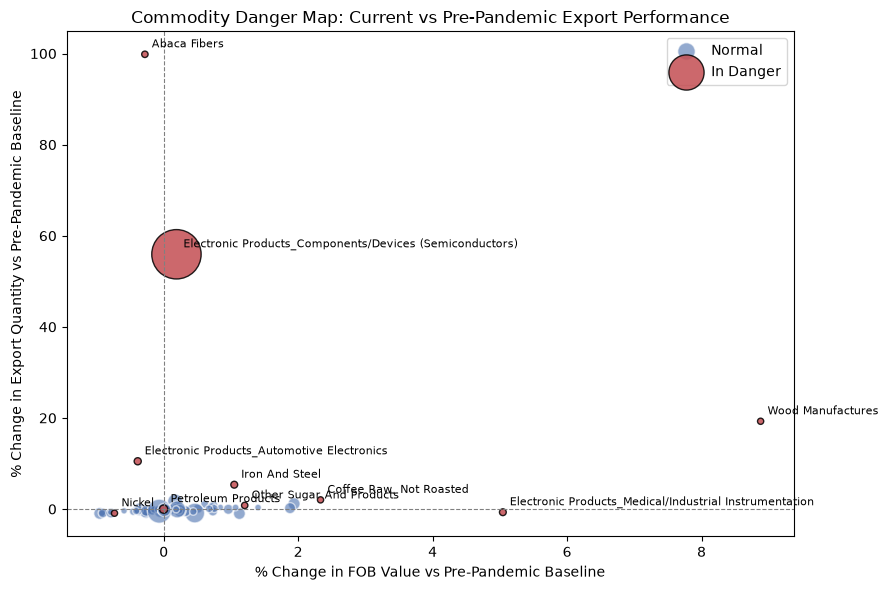

In [7]:
# ---- 4. VISUALIZE: scatter map -------------------------------------------
normal = result[~result["in_danger"]]
danger = result[result["in_danger"]]

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(
    normal["pct_change_fob"], normal["pct_change_qty"],
    s=normal["baseline_fob_share"] * 3000 + 20,
    c="#4C72B0", alpha=0.6, label="Normal", edgecolor="white",
)
ax.scatter(
    danger["pct_change_fob"], danger["pct_change_qty"],
    s=danger["baseline_fob_share"] * 3000 + 20,
    c="#C44E52", alpha=0.85, label="In Danger", edgecolor="black",
)
for _, row in danger.iterrows():
    ax.annotate(
        row["Commodity"], (row["pct_change_fob"], row["pct_change_qty"]),
        fontsize=8, xytext=(5, 5), textcoords="offset points",
    )
ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
ax.axvline(0, color="grey", linewidth=0.8, linestyle="--")
ax.set_xlabel("% Change in FOB Value vs Pre-Pandemic Baseline")
ax.set_ylabel("% Change in Export Quantity vs Pre-Pandemic Baseline")
ax.set_title("Commodity Danger Map: Current vs Pre-Pandemic Export Performance")
ax.legend()
plt.tight_layout()
plt.show()

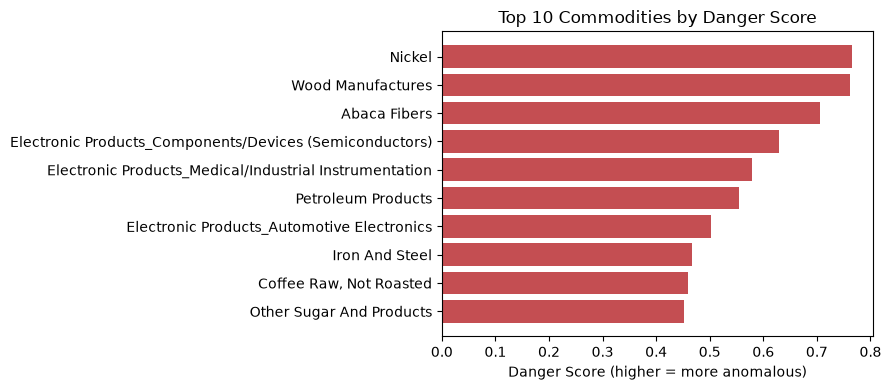

In [8]:
# ---- 4b. VISUALIZE: ranking bar chart -------------------------------------
top = result.head(TOP_N).sort_values("danger_score")

fig, ax = plt.subplots(figsize=(9, max(4, 0.4 * TOP_N)))
colors = ["#C44E52" if d else "#4C72B0" for d in top["in_danger"]]
ax.barh(top["Commodity"], top["danger_score"], color=colors)
ax.set_xlabel("Danger Score (higher = more anomalous)")
ax.set_title(f"Top {TOP_N} Commodities by Danger Score")
plt.tight_layout()
plt.show()

##### 3. Shifts & Predictions

